In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, roc_auc_score
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

df = pd.read_excel("clean_tb_data.xlsx")

# Drop duplicates if any
df = df.drop_duplicates()



In [28]:
print(df.shape)


(7692, 53)


In [29]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

df = df.copy()

df = df.dropna(subset=['Default or not'])

for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype).startswith('category'):
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))


y = df["Default or not"].astype(float)
X = df.drop(columns=["Default or not"])

X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

p_values = model.pvalues.sort_values()
print("Feature p-values:")
print(p_values)


significant_features = p_values[p_values < 0.05].index
significant_features = [f for f in significant_features if f != 'const']

print("\n Significant features (p < 0.05):")
print(significant_features)


X_selected = X[significant_features]
print(f"\n Final selected feature count: {len(X_selected.columns)}")


Feature p-values:
Patient_Status                           2.660577e-193
Treatment_Outcome                        2.459309e-119
Microbiologically_Confirmed               3.439932e-31
Treatment_Outcome_Date                    4.598476e-11
BankDetailsAdded                          1.345925e-10
EPSite                                    4.646325e-10
EpisodeID                                 1.547423e-08
SiteOfDisease                             4.676334e-07
TypeOfCase                                5.650829e-07
YEAR                                      5.678805e-07
const                                     5.881126e-07
ContactTracing_Done                       1.419531e-06
MONTH                                     3.301374e-05
basisOfDiagnosis_LabSerialNo              1.060894e-04
HIV_Status                                7.428381e-04
Residential_District                      1.795297e-03
FollowupDone_Count                        5.698568e-03
EnrollmentFacilityState                   1.294

In [30]:

selected_features = [
    'Microbiologically_Confirmed', 'EPSite', 'EpisodeID', 'SiteOfDisease', 'TypeOfCase', 'YEAR', 'ContactTracing_Done', 'MONTH', 'basisOfDiagnosis_LabSerialNo', 'HIV_Status', 'Residential_District', 'FollowupDone_Count', 'EnrollmentFacilityState', 'TB patients provided support (Yes/No)', 'Age', 'DiabetesStatus'
]

selected_features = [f for f in selected_features if f in df.columns]
y = df["Default or not"]
df = df.dropna(subset=["Default or not"])

X = df[selected_features]


In [31]:


cat_cols = X.select_dtypes(include='object').columns
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

if y.dtype == 'object' or y.dtype == 'str':
    y = y.str.lower().map({'default': 1, 'not-default': 0})



# Fill numeric NaN with median and categorical with mode
for col in X.columns:
    if X[col].dtype in [np.float64, np.int64]:
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode()[0])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#Apply SMOTE on Training Data

print("\nBefore SMOTE:", np.bincount(y_train))
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
print("After SMOTE:", np.bincount(y_train))

input_dim = X_train.shape[1]


class ModifiedReLU(layers.Layer):
    def __init__(self, a=0.01, **kwargs):
        super(ModifiedReLU, self).__init__(**kwargs)
        self.a = a  # slope for positive side

    def call(self, inputs):
        # Multiply positive inputs by a small factor, keep negatives as-is
        return tf.where(inputs > 0, self.a * inputs, inputs)

    def get_config(self):
        config = super().get_config()
        config.update({"a": self.a})
        return config


def create_modified_relu_model(input_dim, a=0.01):
    model = models.Sequential([
        layers.Dense(128, input_shape=(input_dim,)),
        ModifiedReLU(a=a),
        layers.Dropout(0.3),

        layers.Dense(64),
        ModifiedReLU(a=a),
        layers.Dropout(0.3),

        layers.Dense(32),
        ModifiedReLU(a=a),

        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model


cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))
input_dim = X_train.shape[1]
model = create_modified_relu_model(input_dim=input_dim, a=0.01)

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)



Before SMOTE: [1243 4910]


C:\Users\acer\AppData\Local\Temp\ipykernel_20720\3810072036.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())
C:\Users\acer\AppData\Local\Temp\ipykernel_20720\3810072036.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())
C:\Users\acer\AppData\Local\Temp\ipykernel_20720\3810072036.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

After SMOTE: [4910 4910]
Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6864 - loss: 0.5712 - precision_6: 0.6570 - recall_6: 0.7798 - val_accuracy: 0.8231 - val_loss: 0.4752 - val_precision_6: 0.9010 - val_recall_6: 0.8746
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7090 - loss: 0.5448 - precision_6: 0.6661 - recall_6: 0.8381 - val_accuracy: 0.7945 - val_loss: 0.4972 - val_precision_6: 0.9116 - val_recall_6: 0.8225
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7133 - loss: 0.5365 - precision_6: 0.6676 - recall_6: 0.8499 - val_accuracy: 0.7893 - val_loss: 0.4994 - val_precision_6: 0.8951 - val_recall_6: 0.8339
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7190 - loss: 0.5328 - precision_6: 0.6763 - recall_6: 0.8403 - val_accuracy: 0.8257 - val_loss: 0.4617 - val_precision_6: 0.8922 - val_recall_6: 0.8893
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7231 - loss: 0.5272 - precision_6: 0

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Best threshold for NN: 0.30 (F1=0.9288)
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Training Metrics (Threshold=0.30000000000000004):
Accuracy: 0.6983, Precision: 0.6262, F1: 0.7652, Recall: 0.9835, ROC-AUC: 0.8244


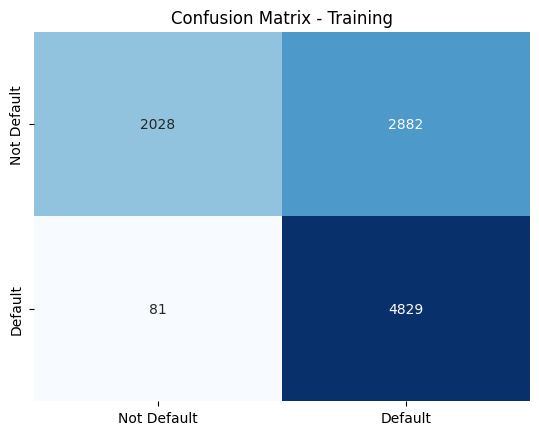

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Validation Metrics (Threshold=0.30000000000000004):
Accuracy: 0.8791, Precision: 0.8759, F1: 0.9288, Recall: 0.9886, ROC-AUC: 0.8259


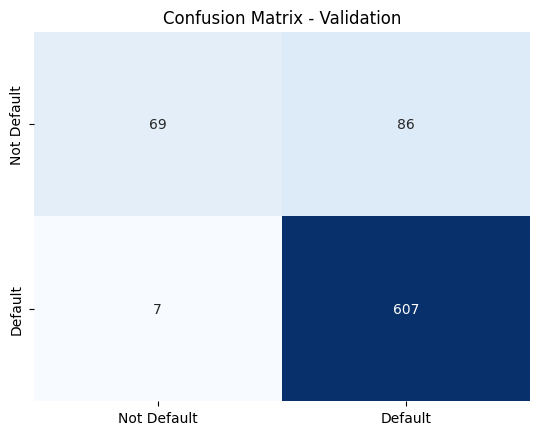

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Test Metrics (Threshold=0.30000000000000004):
Accuracy: 0.8740, Precision: 0.8709, F1: 0.9260, Recall: 0.9886, ROC-AUC: 0.7986


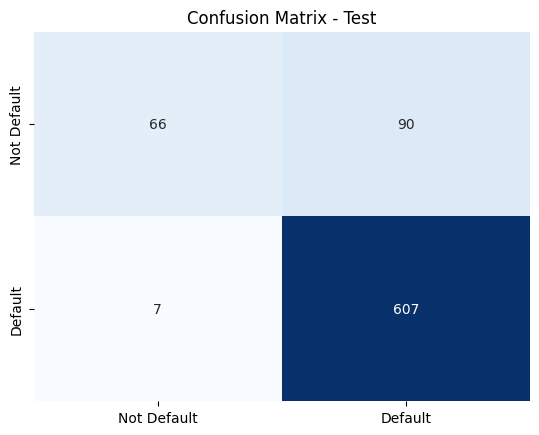

In [32]:
def evaluate_model(model, X, y, set_name, threshold=0.5):
    y_prob = model.predict(X).flatten()
    y_pred = (y_prob > threshold).astype(int)
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    recall = recall_score(y, y_pred)
    prec = precision_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_prob)
    cm = confusion_matrix(y, y_pred)
    print(f"\n{set_name} Metrics (Threshold={threshold}):")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, F1: {f1:.4f}, Recall: {recall:.4f}, ROC-AUC: {roc_auc:.4f}")
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Default', 'Default'],
                yticklabels=['Not Default', 'Default'])
    plt.title(f'Confusion Matrix - {set_name}')
    plt.show()
    return acc, f1, recall, prec, roc_auc

y_val_prob = model.predict(X_val).flatten()
# For simplicity, let's pick threshold that maximizes F1 on val set
thresholds = np.linspace(0.1, 0.9, 9)
best_thresh, best_f1 = 0.5, 0
for t in thresholds:
    y_val_pred = (y_val_prob > t).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
print(f"\nBest threshold for NN: {best_thresh:.2f} (F1={best_f1:.4f})")

train_metrics = evaluate_model(model, X_train, y_train, "Training", threshold=best_thresh)
val_metrics = evaluate_model(model, X_val, y_val, "Validation", threshold=best_thresh)
test_metrics = evaluate_model(model, X_test, y_test, "Test", threshold=best_thresh)


In [ ]:
# Get predicted probabilities
y2_prob = model.predict(X2_scaled).flatten()

# Convert to class labels using BEST threshold
y2_pred = (y2_prob > best_thresh).astype(int)

mapping_df = pd.DataFrame({
    "Person_ID": df2.index,     # Index from second dataset
    "Actual": y2.values,
    "Predicted": y2_pred,
    "Predicted_Probability": y2_prob
})


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [33]:
def compare_models(models_dict, X_train, y_train, X_test, y_test, nn_model=None, nn_threshold=0.5):
    results = []

    # Classical ML models
    for name, clf in models_dict.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1]

        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        acc = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        results.append({
            'Model': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'ROC-AUC': roc_auc
        })

    # Neural Network
    if nn_model is not None:
        y_prob_nn = nn_model.predict(X_test).flatten()
        y_pred_nn = (y_prob_nn > nn_threshold).astype(int)

        results.append({
            'Model': 'Neural Network',
            'Accuracy': accuracy_score(y_test, y_pred_nn),
            'Precision': precision_score(y_test, y_pred_nn, zero_division=0),
            'Recall': recall_score(y_test, y_pred_nn, zero_division=0),
            'F1-Score': f1_score(y_test, y_pred_nn, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, y_prob_nn)
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
    
    print("\nModel Comparison Table:")
    display(results_df)

    # Plot ROC-AUC Comparison
    plt.figure(figsize=(8,5))
    sns.barplot(x='Model', y='ROC-AUC', data=results_df, palette='viridis')
    plt.title("ROC-AUC Comparison of Models")
    plt.ylim(0,1)
    plt.show()

    return results_df


In [34]:
y_train_prob = model.predict(X_train).flatten()
y_train_pred = (y_train_prob > best_thresh).astype(int)

mapping_train = pd.DataFrame({
    "Actual": y_train,
    "Predicted": y_train_pred,
    "Probability": y_train_prob,
    "Correct?": np.where(y_train == y_train_pred, "Correct", "Wrong")
})

print(mapping_train.head())


307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
   Actual  Predicted  Probability Correct?
0       1          1     0.571470  Correct
1       1          1     0.503028  Correct
2       1          1     0.724440  Correct
3       1          1     0.827807  Correct
4       1          1     0.752460  Correct


In [35]:
y_val_prob = model.predict(X_val).flatten()
y_val_pred = (y_val_prob > best_thresh).astype(int)

mapping_val = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": y_val_pred,
    "Probability": y_val_prob,
    "Correct?": np.where(y_val.values == y_val_pred, "Correct", "Wrong")
})

print(mapping_val.head())


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
   Actual  Predicted  Probability Correct?
0       1          1     0.682262  Correct
1       1          1     0.845745  Correct
2       0          1     0.645253    Wrong
3       1          1     0.698127  Correct
4       1          1     0.670052  Correct


In [36]:
y_test_prob = model.predict(X_test).flatten()
y_test_pred = (y_test_prob > best_thresh).astype(int)

mapping_test = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Probability": y_test_prob,
    "Correct?": np.where(y_test.values == y_test_pred, "Correct", "Wrong")
})

print(mapping_test.head())


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
   Actual  Predicted  Probability Correct?
0       1          1     0.527300  Correct
1       1          1     0.708144  Correct
2       1          1     0.563121  Correct
3       1          1     0.737197  Correct
4       1          1     0.786286  Correct


In [37]:
mapping_train.to_excel("Mapping_Train.xlsx", index=False)
mapping_val.to_excel("Mapping_Validation.xlsx", index=False)
mapping_test.to_excel("Mapping_Test.xlsx", index=False)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Neural Network,0.874026,0.870875,0.988599,0.926011,0.798641
1,SVM,0.828571,0.903010,0.879479,0.891089,0.794694
2,Random Forest,0.836364,0.887302,0.910423,0.898714,0.775573
3,Logistic Regression,0.789610,0.884354,0.846906,0.865225,0.775098


C:\Users\acer\AppData\Local\Temp\ipykernel_20720\213244812.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='ROC-AUC', data=results_df, palette='viridis')


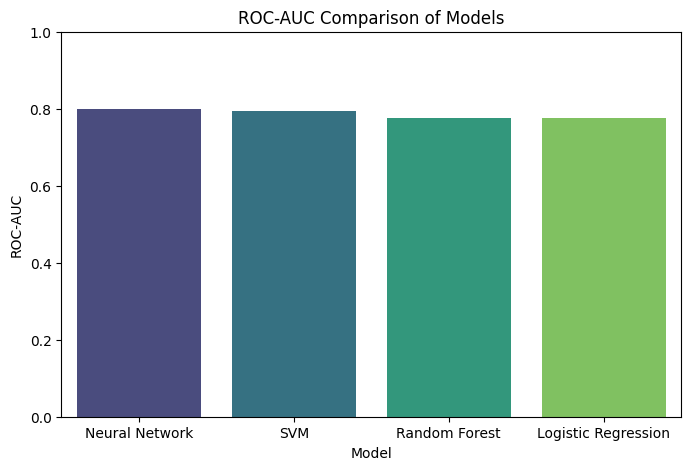

In [38]:
models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM": SVC(probability=True, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

comparison_df = compare_models(models_dict, X_train, y_train, X_test, y_test, nn_model=model, nn_threshold=best_thresh)


In [39]:
from sklearn.metrics import classification_report
# Define the list of loss functions you want to compare
loss_functions = [ 'hinge', 'mean_squared_error']

# To store results
results = {}

for loss_fn in loss_functions:
    print(f" Training with Loss Function: {loss_fn.upper()}")


    # Create the model with ModifiedReLU
    model = create_modified_relu_model(input_dim=input_dim, a=0.01)
    
    # Recompile model with new loss function
    model.compile(
        optimizer='adam',
        loss=loss_fn,
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate on test data
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[loss_fn] = {
        'accuracy': acc,
        'roc_auc': roc_auc,
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1': report['1']['f1-score']
    }

# Show Summary
print("\n===== Summary of Results for Different Loss Functions =====\n")
for loss_fn, metrics in results.items():
    print(f"{loss_fn:25s} | "
          f"Acc: {metrics['accuracy']:.4f} | "
          f"AUC: {metrics['roc_auc']:.4f} | "
          f"P: {metrics['precision']:.3f} | "
          f"R: {metrics['recall']:.3f} | "
          f"F1: {metrics['f1']:.3f}")


 Training with Loss Function: HINGE


c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
 Training with Loss Function: MEAN_SQUARED_ERROR


c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

===== Summary of Results for Different Loss Functions =====

hinge                     | Acc: 0.8506 | AUC: 0.8015 | P: 0.888 | R: 0.930 | F1: 0.909
mean_squared_error        | Acc: 0.8455 | AUC: 0.7970 | P: 0.886 | R: 0.925 | F1: 0.905



===== Summary Table =====


,accuracy,roc_auc,precision,recall,f1
hinge,0.850649,0.80147,0.888025,0.929967,0.908512
mean_squared_error,0.845455,0.79697,0.886115,0.925081,0.905179


<Figure size 1000x600 with 0 Axes>

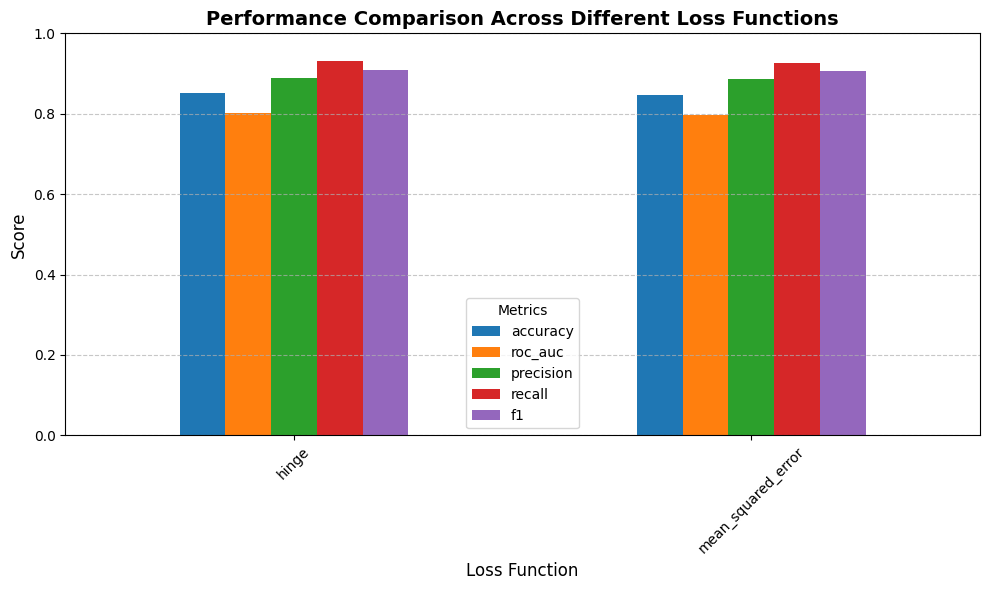

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert results dictionary into a DataFrame
results_df = pd.DataFrame(results).T  # transpose for easier plotting
results_df = results_df[['accuracy', 'roc_auc', 'precision', 'recall', 'f1']]  # order columns

# Display the table
print("\n===== Summary Table =====")
display(results_df)

# Plot comparison bars
plt.figure(figsize=(10, 6))
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Performance Comparison Across Different Loss Functions", fontsize=14, weight='bold')
plt.xlabel("Loss Function", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


C:\Users\acer\AppData\Local\Temp\ipykernel_20720\1394750643.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series = series.replace({
C:\Users\acer\AppData\Local\Temp\ipykernel_20720\1394750643.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series = series.replace({
C:\Users\acer\AppData\Local\Temp\ipykernel_20720\1394750643.py:62: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("\nBefore SMOTE:", np.bincount(y_train))


['Age', 'Gender', 'Weight', 'HIV_Status', 'DiabetesStatus', 'Microbiologically_Confirmed', 'TypeOfCase', 'SiteOfDisease', 'EPSite']

Before SMOTE: [4910 1243]


C:\Users\acer\AppData\Local\Temp\ipykernel_20720\1394750643.py:65: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("After SMOTE:", np.bincount(y_train))
c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


After SMOTE: [4910 4910]
Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6582 - loss: 0.5905 - precision_12: 0.7071 - recall_12: 0.5403 - val_accuracy: 0.8140 - val_loss: 0.5604 - val_precision_12: 0.5441 - val_recall_12: 0.4774
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6898 - loss: 0.5620 - precision_12: 0.8001 - recall_12: 0.5061 - val_accuracy: 0.7997 - val_loss: 0.5683 - val_precision_12: 0.5032 - val_recall_12: 0.5032
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6905 - loss: 0.5563 - precision_12: 0.8101 - recall_12: 0.4978 - val_accuracy: 0.8257 - val_loss: 0.5479 - val_precision_12: 0.5778 - val_recall_12: 0.5032
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6916 - loss: 0.5506 - precision_12: 0.8099 - recall_12: 0.5008 - val_accuracy: 0.8270 - val_loss: 0.5441 - val_precision_12: 0.5846 - val_recall_12: 0.4903
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6973 - loss: 0.5479 

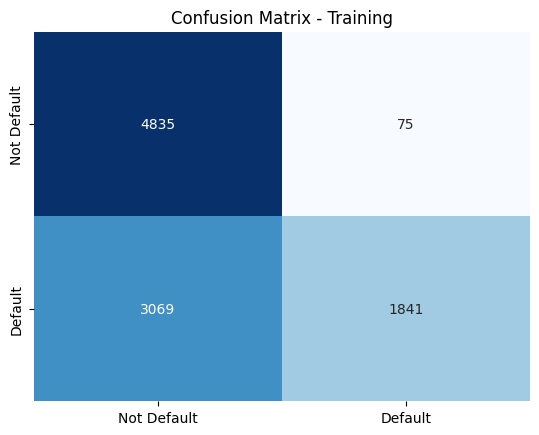

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Validation Metrics (Threshold=0.7000000000000001):
Accuracy: 0.8661, Precision: 0.8611, F1: 0.5463, Recall: 0.4000, ROC-AUC: 0.7331


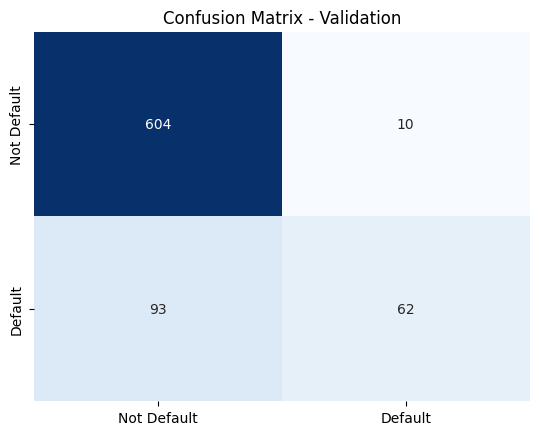

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Test Metrics (Threshold=0.7000000000000001):
Accuracy: 0.8610, Precision: 0.8657, F1: 0.5202, Recall: 0.3718, ROC-AUC: 0.7418


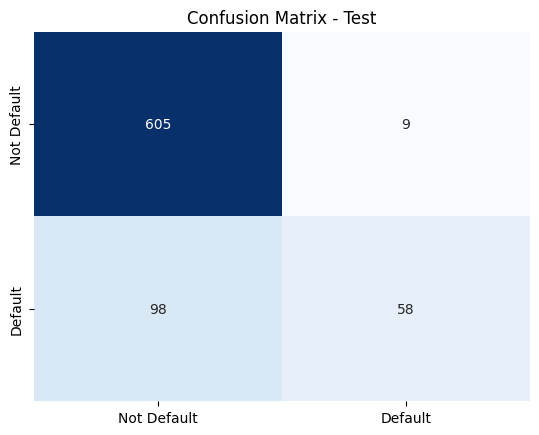

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Second Dataset Metrics (Threshold=0.7000000000000001):
Accuracy: 0.7989, Precision: 0.8632, F1: 0.3653, Recall: 0.2317, ROC-AUC: 0.6382


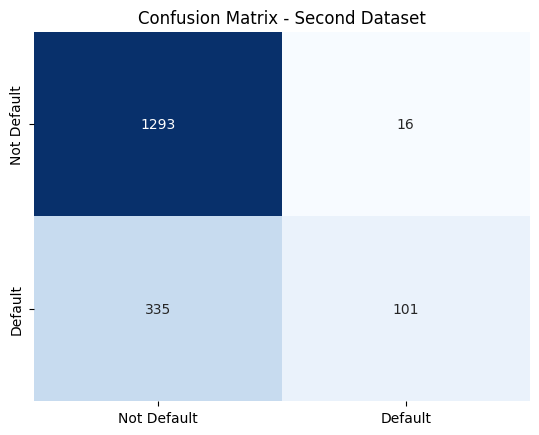

(0.7988538681948424,
 0.36528028933092227,
 0.231651376146789,
 0.8632478632478633,
 0.6381990243970816)

In [ ]:
df1 = pd.read_excel("clean_tb_data.xlsx")   
df2 = pd.read_excel("ds2.xlsx")     

target_col = "Default or not"

df1 = df1.drop_duplicates().dropna(subset=[target_col])
df2 = df2.drop_duplicates().dropna(subset=[target_col])
def encode_target(series):
    series = series.astype(str).str.lower().str.strip()
    series = series.replace({
        "default": 1, "1": 1, "yes": 1, "true": 1,
        "not-default": 0, "no": 0, "false": 0, "0": 0
    })
    # Convert to numeric, coerce errors to NaN
    series = pd.to_numeric(series, errors='coerce')
    return series

df1[target_col] = encode_target(df1[target_col])
df2[target_col] = encode_target(df2[target_col])

common_features = [col for col in df1.columns if col in df2.columns and col != target_col]
common_features.remove("Treatment_Outcome")
print(common_features)

combined = pd.concat([df1[common_features], df2[common_features]], axis=0)
label_encoders = {}
for col in combined.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
    label_encoders[col] = le

df1_encoded = combined.iloc[:len(df1)]
df2_encoded = combined.iloc[len(df1):]

X1 = df1_encoded.copy()
y1 = df1[target_col].astype(float)

X2 = df2_encoded.copy()
y2 = df2[target_col].astype(float)

for df_temp in [X1, X2]:
    for col in df_temp.columns:
        if df_temp[col].dtype in [np.float64, np.int64]:
            df_temp[col] = df_temp[col].fillna(df_temp[col].median())
        else:
            df_temp[col] = df_temp[col].fillna(df_temp[col].mode()[0])

X_train, X_temp, y_train, y_temp = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
X2_scaled = scaler.transform(X2)  

# --- STEP 6: Handle imbalance with SMOTE ---
print("\nBefore SMOTE:", np.bincount(y_train))
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
print("After SMOTE:", np.bincount(y_train))

input_dim = X_train.shape[1]
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

model = create_modified_relu_model(input_dim=input_dim, a=0.01)
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

y_val_prob = model.predict(X_val).flatten()
thresholds = np.linspace(0.1, 0.9, 9)
best_thresh, best_f1 = 0.5, 0
for t in thresholds:
    y_val_pred = (y_val_prob > t).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
print(f"\nBest threshold for NN: {best_thresh:.2f} (F1={best_f1:.4f})")

train_metrics = evaluate_model(model, X_train, y_train, "Training", threshold=best_thresh)
val_metrics = evaluate_model(model, X_val, y_val, "Validation", threshold=best_thresh)
test_metrics = evaluate_model(model, X_test, y_test, "Test", threshold=best_thresh)

evaluate_model(model, X2_scaled, y2, "Second Dataset", threshold=best_thresh)


In [42]:
# Get predicted probabilities
y2_prob = model.predict(X2_scaled).flatten()

# Convert to class labels using BEST threshold
y2_pred = (y2_prob > best_thresh).astype(int)

mapping_df = pd.DataFrame({
    "Person_ID": df2.index,     # Index from second dataset
    "Actual": y2.values,
    "Predicted": y2_pred,
    "Predicted_Probability": y2_prob
})


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [43]:
label_map = {0: "Not Default", 1: "Default"}

mapping_df["Actual_Label"] = mapping_df["Actual"].map(label_map)
mapping_df["Predicted_Label"] = mapping_df["Predicted"].map(label_map)


In [44]:
mapping_df["Correct?"] = np.where(
    mapping_df["Actual"] == mapping_df["Predicted"], "Correct", "Wrong"
)


In [45]:
final_mapping = mapping_df[[
    "Person_ID",
    "Actual_Label",
    "Predicted_Label",
    "Predicted_Probability",
    "Correct?"
]]

print(final_mapping.head(20))


    Person_ID Actual_Label Predicted_Label  Predicted_Probability Correct?
0           0      Default         Default               0.977954  Correct
1           1  Not Default     Not Default               0.074485  Correct
2           2      Default         Default               0.984789  Correct
3           3      Default     Not Default               0.219535    Wrong
4           4      Default     Not Default               0.078681    Wrong
5           5  Not Default     Not Default               0.146876  Correct
6           6  Not Default     Not Default               0.078674  Correct
7           7      Default     Not Default               0.134694    Wrong
8           8  Not Default     Not Default               0.139805  Correct
9           9  Not Default     Not Default               0.068008  Correct
10         10  Not Default     Not Default               0.135357  Correct
11         11  Not Default     Not Default               0.085516  Correct
12         12  Not Defaul

In [46]:
final_mapping.to_excel("Second_Dataset_Prediction_Mapping.xlsx", index=False)
print("File saved: Second_Dataset_Prediction_Mapping.xlsx")


File saved: Second_Dataset_Prediction_Mapping.xlsx


In [47]:
print(df2.shape)
y2.value_counts()

(1745, 84)


Default or not
0.0    1309
1.0     436
Name: count, dtype: int64